# House Prices Kaggle Competition - Advanced Regression

This notebook trains a Random Forest Regressor Model to predict the prices of houses.
 The contents of this notebook include:

- ✅ Library Installation
- ✅ Data loading and Data Preprocessing
- ✅ EDA (Exploratory Data Analysis)
- ✅ Model training with cross-validation and predictions
- ✅ Submission

## 1. Library Import 

In [84]:
import seaborn as sns
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder


## 2. Data Loading and Data Preprocessing

In [85]:
# Base Data import
train_data = pd.read_csv("/kaggle/input/house-prices-advanced-regression-techniques/train.csv",index_col = 0)
test_data = pd.read_csv("/kaggle/input/house-prices-advanced-regression-techniques/test.csv", index_col = 0)

# Model Instance
RF_model = RandomForestRegressor(random_state = 1)

# X = Features (Train and Test) | Target Y
#X_features = ['MSSubClass','LotArea','PoolArea','OverallQual','YearBuilt','OverallCond','Fireplaces',"1stFlrSF",'2ndFlrSF','GrLivArea','FullBath']
#train_X =train_data[X_features]
train_y = train_data.SalePrice
#test_X = test_data[X_features]



In [89]:
# Pipelines for Numerical and Categorical
categorical_cols = [cname for cname in train_data.columns if train_data[cname].nunique() < 10 and 
                        train_data[cname].dtype == "object"]

numerical_cols = [cname for cname in train_data.columns if train_data[cname].dtype in ['int64', 'float64'] and cname != 'SalePrice']
#print(train_data[numerical_cols].isnull().any())

selected_cols = numerical_cols + categorical_cols 
train_X = train_data[selected_cols].copy()
test_X = test_data[selected_cols].copy()

num_pipeline = Pipeline([('imputer' , SimpleImputer(strategy = 'median'))])
cat_pipeline = Pipeline(steps =[('imputer', SimpleImputer(strategy = 'most_frequent')),
                                ('onehot',OneHotEncoder(handle_unknown = 'ignore' ))])

preprocessor = ColumnTransformer(transformers =[
    ('num', num_pipeline, numerical_cols),
    ('cat', cat_pipeline,categorical_cols)
])

# Combining Preprocessor and Random Forest into 1 pipeline
pipeline = Pipeline(steps = [
    ('preprocessor',preprocessor),
    ('model',RF_model)
])


pipeline.fit(train_X,train_y)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['MSSubClass', 'LotFrontage',
                                                   'LotArea', 'OverallQual',
                                                   'OverallCond', 'YearBuilt',
                                                   'YearRemodAdd', 'MasVnrArea',
                                                   'BsmtFinSF1', 'BsmtFinSF2',
                                                   'BsmtUnfSF', 'TotalBsmtSF',
                                                   '1stFlrSF', '2ndFlrSF',
                                                   'LowQualFinSF', 'GrLivArea',
                                                   'BsmtFull...
                                                   'LotConfig', 'LandSlope',
                                                   'Condition1', 'Condition2',
                                                   'BldgType', 'HouseStyle',
                                                   'RoofStyle', 'RoofMatl',
                                                   'MasVnrType', 'ExterQual',
                                                   'ExterCond', 'Foundation',
                                                   'BsmtQual', 'BsmtCond',
                                                   'BsmtExposure',
                                                   'BsmtFinType1',
                                                   'BsmtFinType2', 'Heating',
                                                   'HeatingQC', 'CentralAir',
                                                   'Electrical', 'KitchenQual',
                                                   'Functional', 'FireplaceQu', ...])])),
                ('model', RandomForestRegressor(random_state=1))])

## 2. EDA - (Exploratory Data Analysis) 

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/tmp/ipykernel_35/1587410987.py:12: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singul

Neighborhood
NAmes      225
CollgCr    150
OldTown    113
Edwards    100
Somerst     86
Gilbert     79
NridgHt     77
Sawyer      74
NWAmes      73
SawyerW     59
BrkSide     58
Crawfor     51
Mitchel     49
NoRidge     41
Timber      38
IDOTRR      37
ClearCr     28
StoneBr     25
SWISU       25
MeadowV     17
Blmngtn     17
BrDale      16
Veenker     11
NPkVill      9
Blueste      2
Name: count, dtype: int64

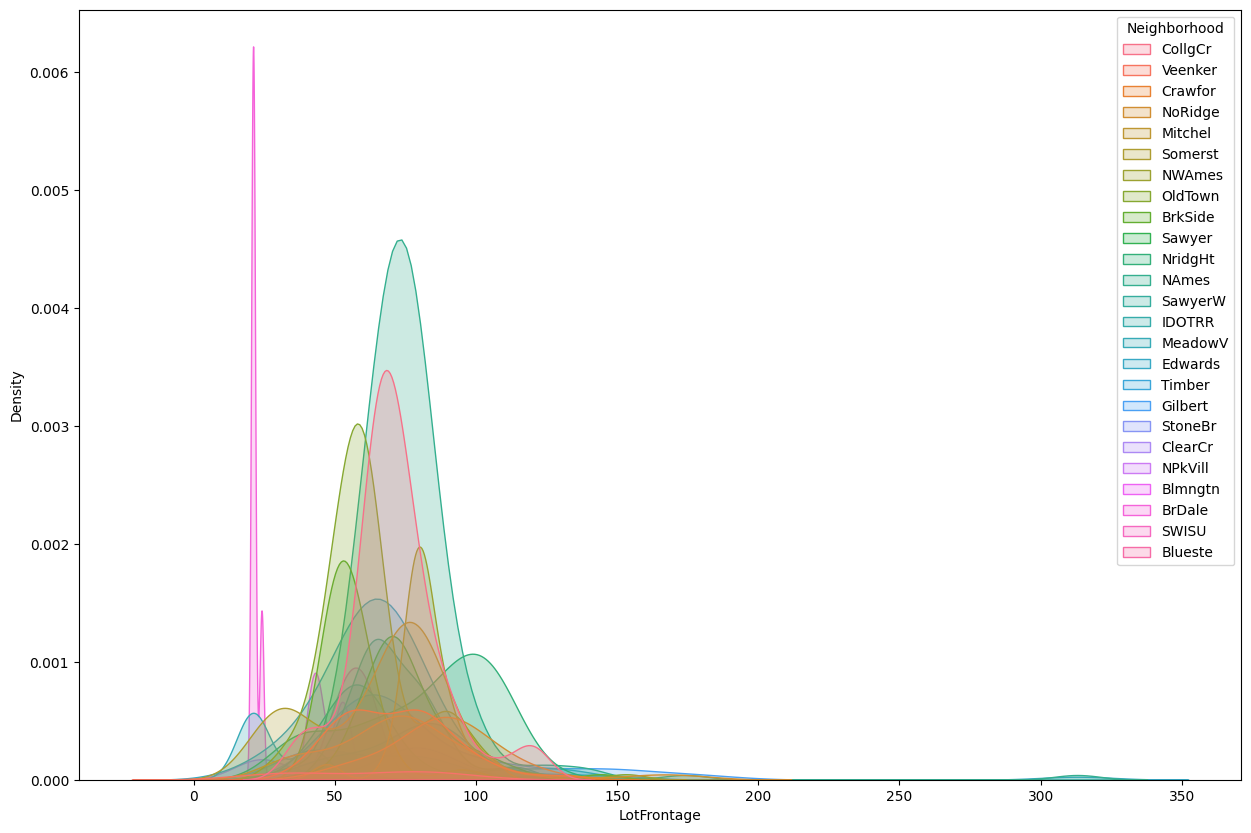

In [91]:
 
plt.figure(figsize=(15, 10))
#sns.kdeplot(data=train_data, x='LotArea', fill = True, hue = 'LotShape')
#sns.lmplot(data=train_data, x='LotArea',y = 'SalePrice', hue = 'Functional')
#train_data.Functional.value_counts()
#sns.kdeplot(data=train_data, x='SalePrice', hue = 'BldgType', fill = True )
#sns.boxplot(data=train_data, y='SalePrice', x = 'Fireplaces')
#sns.kdeplot(data=train_data, x = 'MiscVal')
#sns.kdeplot(data=train_data, x = 'Fireplaces', fill = True)
#sns.regplot(data=train_data, y='SalePrice', x = '2ndFlrSF')
#sns.regplot(data=train_data, y='SalePrice', x = 'GarageArea')
#sns.heatmap(train_X.corr(), annot=True)
sns.kdeplot(data=train_data, x='LotFrontage', fill = True, hue = "Neighborhood")



train_data.Neighborhood.value_counts()

In [93]:
train_data.Fireplaces.value_counts()
test_X.shape

(1459, 76)

## 3. Model training with cross-validation and predictions

In [94]:

y_pred = pipeline.predict(test_X)
y_pred

scores = -1 * cross_val_score(pipeline, train_X, train_y,
                             cv =5,
                             scoring = 'neg_mean_absolute_error')

print("Average MAE Score: ", scores.mean())



Average MAE Score:  17703.416054794518


## 4. Submission

In [97]:
submission = pd.DataFrame({"SalePrice":y_pred},index=test_X.index)
submission.to_csv("submission.csv")